In [2]:
import pandas as pd
from tqdm import tqdm
import pymorphy3
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
#простой пример - классификация заявок в жкх
df = pd.read_csv(r'C:\Users\User\ML_Competitions\Templates\Text_Processing\zayavki_text.csv')
df.head()

,Unnamed: 0,text,category,id_category
0,0,"1й подъезд, 5 этаж. В коридоре над висит ка...",Содержание МКД,10
1,1,Маленькмй лифт изрисован внутри.,Содержание МКД,10
2,2,реклама на светофоре,Благоустройство,3
3,3,"1й подъезд, 5 этаж, квартирный холл. Рааботник...",Содержание МКД,10
4,4,незаконная решетка на фасаде,Нарушение правил пользования общим имуществом,23


## Базовая обработка

PyMorphy3 – морфологический анализатор русских текстов, который работает с морфологическим словарем OpenCorpora (http://opencorpora.org/), создаваемым на основе базы данных «Грамматического словаря русского языка»

PyMorphy3 – морфологический анализатор русских текстов, который работает с морфологическим словарем OpenCorpora (http://opencorpora.org/), создаваемым на основе базы данных «Грамматического словаря русского языка»

In [4]:
# 1 - только буквы
# 2 - перевод в нижний регистр
# 3 - привести все слова в единую форму
tqdm.pandas()
morph=pymorphy3.MorphAnalyzer()
def process_text(text):
    s = re.sub(r'[^\w\s]+|[\d]+', r'',text).strip()
    s = s.lower()
    s1 = word_tokenize(s) #токенизация
    words=[]
    for i in s1:
        pv = morph.parse(i)
        words.append(pv[0].normal_form)
    sentence=' '.join(words)
    return sentence

df['process_text']=df.text.progress_apply(process_text)

100%|██████████| 59889/59889 [02:39<00:00, 375.23it/s]


## Векторизация

CountVectorizer считает встречаемость слов в документе. Под документом может подразумеваться предложение, абзац, пост или комментарий. Результатом применения CountVectorizer являются разреженные вектора (sparse vectors), причём значения сортированы согласно частоте встречаемости слова.

In [5]:

#count_vectorizer
russian_stopwords = stopwords.words("russian") #стоп-слова
vectorizer_cv = CountVectorizer(max_features=500, min_df=20, max_df=0.7, stop_words=russian_stopwords) #настройка параметров индивидуально под набор данных
text_cv = vectorizer_cv.fit_transform(df['process_text'])
text_cv_df = pd.DataFrame(text_cv.toarray(),columns=vectorizer_cv.get_feature_names_out())
text_cv_df.head()


,httpgorodgovspbruproblems,аварийный,автомобиль,административный,администрация,адрес,арка,асфальт,асфальтовый,бак,...,щит,щиток,элемент,этаж,это,являться,ям,яма,январь,ящик
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Term Frequency-Inverse Document Frequency (TF-IDF) — это один из наиболее распространенных и мощных методов для извлечения признаков из текстовых данных. TF-IDF вычисляет важность каждого слова в документе относительно количества его употреблений в данном документе и во всей коллекции текстов. Этот метод позволяет выделить ключевые слова и понять, какие слова имеют больший вес для определенного документа в контексте всей коллекции.

In [6]:
vectorizer_tfidf = TfidfVectorizer(max_features=500, min_df=20, max_df=0.7, stop_words=russian_stopwords)
text_tfidf = vectorizer_tfidf.fit_transform(df['process_text'])
text_tfidf_df = pd.DataFrame(text_tfidf.toarray(),columns=vectorizer_tfidf.get_feature_names_out())
text_tfidf_df.head()

,httpgorodgovspbruproblems,аварийный,автомобиль,административный,администрация,адрес,арка,асфальт,асфальтовый,бак,...,щит,щиток,элемент,этаж,это,являться,ям,яма,январь,ящик
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.202361,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.138368,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


СОВЕТ: TF-IDF ПОЧТИ ВСЕГДА ЛУЧШЕ ОБЫЧНОГО МЕШКА СЛОВ

## ВИЗУАЛИЗАЦИЯ ДАННЫХ

Самый простой способ - облако слов. Если классов немного - рисуем для каждого, подмечаем наборы слов, которые характерны для каждого класса.

In [7]:
text_example = df[df['category']=='Подвалы']['process_text'].values
text_example = ' '.join(text_example)

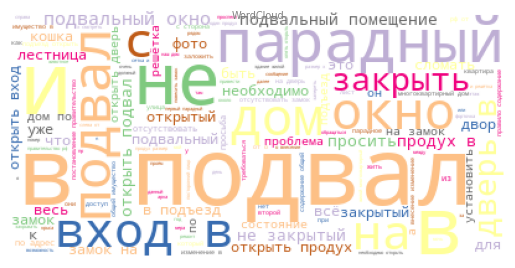

In [8]:
fig = plt.figure()
fig.patch.set_facecolor('white')
plt.subplots_adjust(wspace=0.3, hspace=0.2)

wordcloud = WordCloud(colormap='Accent', background_color='white', contour_width=10).generate(text_example)
plt.tick_params(labelsize=10)
plt.imshow(wordcloud)
plt.axis("off")
plt.title('WordCloud',fontdict={'fontsize':7,'color':'grey'},y=0.93)
plt.tick_params(labelsize=10)

Понижение размерности - берем наши вектора и сжимаем до 2 или 3 компонентов -  используем любой метод (быстрее всего PCA)

In [ ]:
def show_fig(new_shape,df,label):
    #можно добавить раскраску по классам\
    fig = go.Figure(go.Scatter3d(x=new_shape[:, 0],
                        y=new_shape[:, 1],
                        z=new_shape[:, 2],
                        marker=dict(opacity=0.9,
                                    reversescale=True,
                                    colorscale='Blues',
                                    size=5),
                        line=dict (width=0.02),
                        mode='markers',
                                 text=df[label]))
    fig.update_layout(
        scene = dict(
            xaxis = dict(nticks=4),
                         yaxis = dict(nticks=4),
                         zaxis = dict(nticks=4),),
        width=700,
        margin=dict(r=20, l=10, b=10, t=10))
    fig.show()

In [10]:
from sklearn.decomposition import PCA
import plotly.graph_objs as go


pca=PCA(n_components=3)
reduced_pca = pca.fit_transform(text_tfidf_df)
show_fig(reduced_pca,df,'category')

## Классификация текста

На том этапе, когда уже получены вектора, можно использовать что угодно - от логита до catboost

In [11]:
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense
import numpy as np

In [12]:
encoder = LabelEncoder() #кодируем каждую метку класса числом
y = encoder.fit_transform(df['category'])
y = to_categorical(y)

Пробуем взять данные с CountVectorizer

In [13]:
scal_cv = StandardScaler()
scal_X_cv = scal_cv.fit_transform(text_cv_df)
scal_X_cv = pd.DataFrame(scal_X_cv, columns=text_cv_df.columns)

In [14]:
X_train_full,X_test,y_train_full,y_test = train_test_split(scal_X_cv,y,test_size=0.2,random_state=0)
X_train,X_valid,y_train,y_valid = train_test_split(X_train_full,y_train_full,test_size=0.2,random_state=0)

In [15]:
model = keras.models.Sequential()
model.add(Dense(500, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(256, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(y.shape[1], activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=["accuracy"])

history=model.fit(X_train, y_train, epochs =5,batch_size=5,validation_data=(X_valid,y_valid))

acc=model.evaluate(X_test,y_test)
print(np.array(acc)[1].round(2))

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/5
7666/7666 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - accuracy: 0.8422 - loss: 0.5757 - val_accuracy: 0.8886 - val_loss: 0.3942
Epoch 2/5
7666/7666 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - accuracy: 0.9052 - loss: 0.3215 - val_accuracy: 0.9006 - val_loss: 0.3653
Epoch 3/5
7666/7666 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - accuracy: 0.9193 - loss: 0.2709 - val_accuracy: 0.9030 - val_loss: 0.3609
Epoch 4/5
7666/7666 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - accuracy: 0.9261 - loss: 0.2484 - val_accuracy: 0.9051 - val_loss: 0.4089
Epoch 5/5
7666/7666 ━━━━━━━━━━━━━━━━━━━━ 43s 6ms/step - accuracy: 0.9320 - loss: 0.2350 - val_accuracy: 0.9084 - val_loss: 0.4006
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9019 - loss: 0.4361
0.9


А теперь TFIDF

In [16]:
X_train_full,X_test,y_train_full,y_test = train_test_split(text_tfidf_df,y,test_size=0.2,random_state=0)
X_train,X_valid,y_train,y_valid = train_test_split(X_train_full,y_train_full,test_size=0.2,random_state=0)

In [17]:
model = keras.models.Sequential()
model.add(Dense(500, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(256, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(y.shape[1], activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=["accuracy"])

history=model.fit(X_train, y_train, epochs =5,batch_size=5,validation_data=(X_valid,y_valid))

acc=model.evaluate(X_test,y_test)
print(np.array(acc)[1].round(2))

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/5
7666/7666 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.8416 - loss: 0.5601 - val_accuracy: 0.9064 - val_loss: 0.3186
Epoch 2/5
7666/7666 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.9161 - loss: 0.2759 - val_accuracy: 0.9157 - val_loss: 0.2894
Epoch 3/5
7666/7666 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.9333 - loss: 0.2141 - val_accuracy: 0.9128 - val_loss: 0.3023
Epoch 4/5
7666/7666 ━━━━━━━━━━━━━━━━━━━━ 43s 6ms/step - accuracy: 0.9465 - loss: 0.1703 - val_accuracy: 0.9133 - val_loss: 0.3373
Epoch 5/5
7666/7666 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.9543 - loss: 0.1461 - val_accuracy: 0.9158 - val_loss: 0.3616
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9102 - loss: 0.3955
0.91


Tokenizer Keras

Используем Tokenizer, который может векторизовать текстовый массив в список целых чисел. Каждое целое число соответствует значению в словаре, который кодирует весь корпус, причем ключами в словаре являются сами словарные термины. Вы можете добавить параметр num_words, который отвечает за настройку размера словарного запаса. Затем будут сохранены наиболее распространенные слова num_words.

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [21]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['process_text'])

X = tokenizer.texts_to_sequences(df['process_text'])

vocab_size = len(tokenizer.word_index) + 1

In [22]:
print(df['process_text'][0])
print(X[0])

й подъезд этаж в коридор над висеть какойтый провод возможно под напряжение председатель тсж ленинградский вечер отказываться принимать заявка на устранение более полгода
[253, 14, 10, 2, 581, 237, 275, 1775, 212, 442, 134, 2531, 1137, 313, 2034, 779, 1253, 937, 153, 1, 427, 208, 1334]


In [23]:
from tensorflow.keras.utils import pad_sequences
maxlen = 100

X = pad_sequences(X, padding='post', maxlen=maxlen)

print(X[0, :])

[ 253   14   10    2  581  237  275 1775  212  442  134 2531 1137  313
 2034  779 1253  937  153    1  427  208 1334    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [24]:
from keras import layers

embedding_dim = 100

model = Sequential()
model.add(layers.Embedding(input_dim=vocab_size,
                           output_dim=embedding_dim,
                           input_length=maxlen))
model.add(layers.Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dense(y.shape[1], activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=["accuracy"])
model.summary()

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
X_train_full,X_test,y_train_full,y_test = train_test_split(X,y,test_size=0.2,random_state=0)
X_train,X_valid,y_train,y_valid = train_test_split(X_train_full,y_train_full,test_size=0.2,random_state=0)

In [26]:
history=model.fit(X_train, y_train, epochs =5,batch_size=5,validation_data=(X_valid,y_valid))

acc=model.evaluate(X_test,y_test)
print(np.array(acc)[1].round(2))

Epoch 1/5
7666/7666 ━━━━━━━━━━━━━━━━━━━━ 182s 24ms/step - accuracy: 0.8214 - loss: 0.6429 - val_accuracy: 0.9190 - val_loss: 0.2852
Epoch 2/5
7666/7666 ━━━━━━━━━━━━━━━━━━━━ 182s 24ms/step - accuracy: 0.9457 - loss: 0.1772 - val_accuracy: 0.9220 - val_loss: 0.2820
Epoch 3/5
7666/7666 ━━━━━━━━━━━━━━━━━━━━ 181s 24ms/step - accuracy: 0.9657 - loss: 0.1118 - val_accuracy: 0.9141 - val_loss: 0.3567
Epoch 4/5
7666/7666 ━━━━━━━━━━━━━━━━━━━━ 181s 24ms/step - accuracy: 0.9745 - loss: 0.0851 - val_accuracy: 0.9175 - val_loss: 0.4185
Epoch 5/5
7666/7666 ━━━━━━━━━━━━━━━━━━━━ 186s 24ms/step - accuracy: 0.9796 - loss: 0.0707 - val_accuracy: 0.9114 - val_loss: 0.5348
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9047 - loss: 0.5920
0.9


## Сохранение и функция для дальнейшего использования

In [ ]:
import pickle
with open('encoder.pickle', 'wb') as handle:
    pickle.dump(encoder, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
model.save('/content/drive/MyDrive/ML/model.keras')

In [ ]:
def predict_class(tokenizer, model,encoder, maxlen,text):
  vector = tokenizer.texts_to_sequences([text])
  vector_x = pad_sequences(vector, padding='post', maxlen=maxlen)
  y_preds = model.predict(vector_x)
  y_class = y_preds.argmax(axis=-1)
  return encoder.inverse_transform(y_class)[0]